# Formalization 2 — Markov Kernel Hierarchy over Psychological Regimes

This notebook treats the hierarchy as a dynamic state system.

Instead of only building regions, we define transitions between regions:

\[
K_t(v,u) = \mathbb{P}(Z_{t+1}=u \mid Z_t=v, x_t)
\]

Here \(Z_t\) is a latent or inferred psychological-market state.

## Mathematical object

Let \(S_t\) be the set of active hierarchy states at time \(t\).  
A Markov kernel is a map:

\[
K_t: S_t \times \mathcal{B}(S_{t+1}) \to [0,1]
\]

satisfying:

\[
K_t(s, S_{t+1}) = 1
\]

If \(p_t\in\Delta(S_t)\) is the distribution over current states, then:

\[
p_{t+1}(u)=\sum_{s\in S_t}p_t(s)K_t(s,u)
\]

In model form, we learn:

\[
K_\theta(s_t,x_t)=\operatorname{softmax}(f_\theta(s_t,x_t))
\]

This makes the hierarchy trainable as a probabilistic state transition model.

In [1]:
import math
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except Exception as e:
    TORCH_AVAILABLE = False
    print("PyTorch is not available in this environment:", repr(e))

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)

In [2]:
def make_synthetic_market_data(n_steps: int = 2500, seed: int = 42) -> pd.DataFrame:
    """
    Synthetic market-like data with latent psychological regimes.

    Regimes:
    0 = calm accumulation
    1 = greedy trend
    2 = fear selloff
    3 = noisy transition

    This is not meant to simulate real markets faithfully.
    It exists so the hierarchy code can run without external data.
    Replace this function with a real OHLCV loader when you have data.
    """
    rng = np.random.default_rng(seed)

    transition = np.array([
        [0.965, 0.020, 0.005, 0.010],
        [0.025, 0.940, 0.015, 0.020],
        [0.025, 0.020, 0.935, 0.020],
        [0.250, 0.250, 0.250, 0.250],
    ])

    drift = np.array([0.00015, 0.00125, -0.00155, 0.00000])
    vol = np.array([0.006, 0.010, 0.017, 0.012])
    volume_mu = np.array([0.0, 0.45, 0.75, 0.25])
    volume_sigma = np.array([0.25, 0.35, 0.45, 0.40])

    regimes = np.zeros(n_steps, dtype=int)
    returns = np.zeros(n_steps)
    volume_z = np.zeros(n_steps)

    regimes[0] = 0
    for t in range(1, n_steps):
        regimes[t] = rng.choice(4, p=transition[regimes[t - 1]])
        r = drift[regimes[t]] + vol[regimes[t]] * rng.standard_normal()

        # Occasional regime-specific impulse.
        if regimes[t] == 1 and rng.random() < 0.020:
            r += abs(rng.normal(0.018, 0.007))
        if regimes[t] == 2 and rng.random() < 0.030:
            r -= abs(rng.normal(0.026, 0.010))

        returns[t] = r
        volume_z[t] = rng.normal(volume_mu[regimes[t]], volume_sigma[regimes[t]])

    price = 100.0 * np.exp(np.cumsum(returns))
    volume = np.exp(volume_z) * 1_000_000

    df = pd.DataFrame({
        "t": np.arange(n_steps),
        "close": price,
        "return": returns,
        "volume": volume,
        "latent_regime": regimes,
    })

    df["future_return_5"] = df["close"].shift(-5) / df["close"] - 1.0
    df["target_up_5"] = (df["future_return_5"] > 0).astype(int)
    df = df.dropna().reset_index(drop=True)
    return df

df = make_synthetic_market_data()
df.head()

,t,close,return,volume,latent_regime,future_return_5,target_up_5
0,0,100.000000,0.000000,1.000000e+06,0,-0.007029,0
1,1,99.392860,-0.006090,1.206366e+06,0,0.001400,1
2,2,98.250867,-0.011556,7.221338e+05,0,0.012888,1
3,3,98.079327,-0.001747,9.958085e+05,0,0.022283,1
4,4,98.612991,0.005426,1.214640e+06,0,0.014757,1


In [3]:
def rolling_zscore(x: pd.Series, window: int, eps: float = 1e-8) -> pd.Series:
    mean = x.rolling(window, min_periods=window // 2).mean()
    std = x.rolling(window, min_periods=window // 2).std()
    return (x - mean) / (std + eps)

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def make_market_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["ret_1"] = out["close"].pct_change().fillna(0.0)
    out["ret_5"] = out["close"].pct_change(5).fillna(0.0)
    out["ret_20"] = out["close"].pct_change(20).fillna(0.0)
    out["vol_10"] = out["ret_1"].rolling(10, min_periods=5).std().fillna(0.0)
    out["vol_30"] = out["ret_1"].rolling(30, min_periods=10).std().fillna(0.0)
    out["volume_z_20"] = rolling_zscore(np.log(out["volume"]), 20).fillna(0.0)
    out["drawdown_30"] = out["close"] / out["close"].rolling(30, min_periods=10).max() - 1.0
    out["trend_pressure"] = rolling_zscore(out["ret_5"], 30).fillna(0.0)
    out["fear_pressure"] = (-3.0 * out["drawdown_30"] + 2.0 * out["vol_10"] + 0.40 * out["volume_z_20"])
    out["greed_pressure"] = (2.5 * out["ret_20"] + 1.0 * out["trend_pressure"] + 0.25 * out["volume_z_20"])
    out["fear_index"] = sigmoid_np(out["fear_pressure"].clip(-8, 8))
    out["greed_index"] = sigmoid_np(out["greed_pressure"].clip(-8, 8))
    return out.fillna(0.0)

features_df = make_market_features(df)
features_df[["t", "close", "ret_5", "ret_20", "vol_10", "volume_z_20", "fear_index", "greed_index", "target_up_5"]].head()

,t,close,ret_5,ret_20,vol_10,volume_z_20,fear_index,greed_index,target_up_5
0,0,100.000000,0.0,0.0,0.000000,0.0,0.0,0.5,0
1,1,99.392860,0.0,0.0,0.000000,0.0,0.0,0.5,1
2,2,98.250867,0.0,0.0,0.000000,0.0,0.0,0.5,1
3,3,98.079327,0.0,0.0,0.000000,0.0,0.0,0.5,1
4,4,98.612991,0.0,0.0,0.006385,0.0,0.0,0.5,1


## Build discrete states from greed/fear quantiles

We create a finite state space.  
Each state corresponds to a rectangular regime cell.

In [4]:
def assign_regime_cells(frame: pd.DataFrame, n_bins: int = 4) -> pd.DataFrame:
    out = frame.copy()
    out["greed_bin"] = pd.qcut(out["greed_index"], q=n_bins, labels=False, duplicates="drop")
    out["fear_bin"] = pd.qcut(out["fear_index"], q=n_bins, labels=False, duplicates="drop")
    out["state"] = out["greed_bin"].astype(int) * n_bins + out["fear_bin"].astype(int)
    return out

state_df = assign_regime_cells(features_df, n_bins=4)
n_states = int(state_df["state"].max()) + 1

transition_counts = np.zeros((n_states, n_states), dtype=float)
states = state_df["state"].to_numpy()

for a, b in zip(states[:-1], states[1:]):
    transition_counts[a, b] += 1.0

transition_probs = (transition_counts + 1.0)
transition_probs = transition_probs / transition_probs.sum(axis=1, keepdims=True)

pd.DataFrame(transition_probs).round(3).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.225,0.137,0.110,0.060,0.088,0.093,0.066,0.066,0.033,0.011,0.033,0.033,0.011,0.011,0.011,0.011
1,0.133,0.211,0.183,0.094,0.050,0.083,0.067,0.061,0.006,0.017,0.011,0.044,0.011,0.006,0.017,0.006
2,0.107,0.136,0.148,0.243,0.024,0.041,0.107,0.071,0.012,0.030,0.018,0.030,0.006,0.006,0.006,0.018
3,0.096,0.127,0.185,0.268,0.013,0.013,0.057,0.102,0.013,0.013,0.025,0.045,0.006,0.013,0.013,0.013
4,0.075,0.066,0.031,0.026,0.229,0.079,0.048,0.040,0.057,0.110,0.070,0.075,0.018,0.018,0.026,0.031


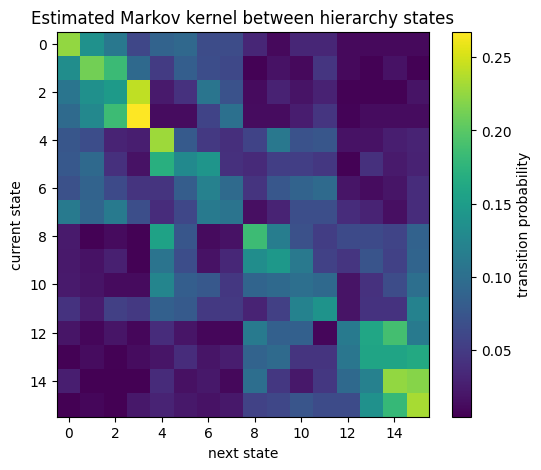

In [5]:
plt.figure(figsize=(6, 5))
plt.imshow(transition_probs, aspect="auto")
plt.colorbar(label="transition probability")
plt.xlabel("next state")
plt.ylabel("current state")
plt.title("Estimated Markov kernel between hierarchy states")
plt.show()

## Train a neural Markov kernel

Input:

- current state one-hot vector
- current price/volume features
- greed/fear indices

Output:

- distribution over next hierarchy state

In [6]:
if not TORCH_AVAILABLE:
    raise RuntimeError("This training section requires PyTorch.")

kernel_features = ["ret_1", "ret_5", "ret_20", "vol_10", "vol_30", "volume_z_20", "drawdown_30", "greed_index", "fear_index"]

class KernelDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, feature_columns: List[str], n_states: int):
        x_numeric = frame[feature_columns].astype("float32").to_numpy()[:-1]
        current_state = frame["state"].astype("int64").to_numpy()[:-1]
        next_state = frame["state"].astype("int64").to_numpy()[1:]

        x_state = np.eye(n_states, dtype=np.float32)[current_state]
        self.x = np.concatenate([x_numeric, x_state], axis=1).astype("float32")
        self.y = next_state.astype("int64")

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return torch.tensor(self.x[idx]), torch.tensor(self.y[idx])

class NeuralMarkovKernel(nn.Module):
    def __init__(self, n_input: int, n_states: int, hidden: int = 96):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_input, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_states),
        )

    def forward(self, x):
        return self.net(x)

def split_by_time(frame, train_frac=0.70, val_frac=0.15):
    n = len(frame)
    a = int(n * train_frac)
    b = int(n * (train_frac + val_frac))
    return frame.iloc[:a].copy(), frame.iloc[a:b].copy(), frame.iloc[b:].copy()

train_frame, val_frame, test_frame = split_by_time(state_df)

train_ds = KernelDataset(train_frame, kernel_features, n_states)
val_ds = KernelDataset(val_frame, kernel_features, n_states)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

model = NeuralMarkovKernel(n_input=len(kernel_features) + n_states, n_states=n_states)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)

history = []
for epoch in range(1, 31):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item()) * len(xb)

    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            val_loss += float(loss.item()) * len(xb)
            pred = logits.argmax(dim=1)
            correct += int((pred == yb).sum().item())
            total += len(xb)

    history.append({
        "epoch": epoch,
        "train_loss": total_loss / len(train_ds),
        "val_loss": val_loss / len(val_ds),
        "val_next_state_accuracy": correct / max(total, 1),
    })

kernel_history = pd.DataFrame(history)
kernel_history.tail()

,epoch,train_loss,val_loss,val_next_state_accuracy
25,26,2.272318,2.409751,0.203753
26,27,2.261375,2.411566,0.209115
27,28,2.257216,2.400447,0.193029
28,29,2.253823,2.450651,0.190349
29,30,2.251476,2.410207,0.195710


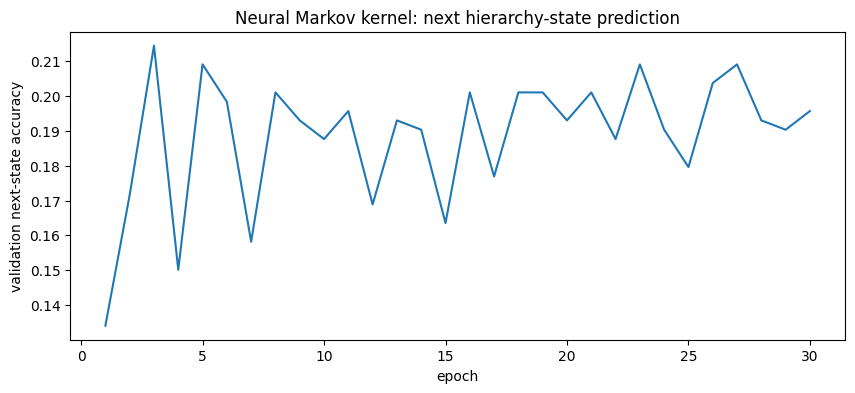

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(kernel_history["epoch"], kernel_history["val_next_state_accuracy"])
plt.xlabel("epoch")
plt.ylabel("validation next-state accuracy")
plt.title("Neural Markov kernel: next hierarchy-state prediction")
plt.show()

## How this becomes meaningful

This formalization is meaningful if the learned transition matrix/kernel reveals:

- stable transition asymmetries;
- paths from calm → greed → transition → fear;
- early warning transitions before large movement;
- better next-state prediction than a frequency-only Markov baseline.

This is not merely a feature list.  
It is a hypothesis about market behavior as a transition law between psychological regions.